# Bank Marketing — Baseline Modeling

## 1. Introduction

### 1.1 Objective & Scope

This notebook establishes a reproducible Logistic Regression
baseline for the Bank Marketing project.

The business objective is to rank customers by predicted
subscription probability so that limited call-center resources
can prioritize promising customers.

**Prediction time:** immediately before a planned marketing contact.

The objectives are to:

- Reproduce the established chronological split.
- Reconstruct the baseline preprocessing configuration.
- Define and train the baseline model.
- Evaluate Validation ranking performance.
- Record a common reference for subsequent experiments.

Model comparison, preprocessing experiments, hyperparameter tuning,
and final Test evaluation are handled in later notebooks.

This notebook runs independently of objects created in
Notebooks 01 and 02.

### 1.2 Baseline Strategy

Use Logistic Regression as the initial predictive baseline.

It provides a relatively simple model and supports probability
scores for customer ranking.

Preserve the preprocessing configuration from
`02-preprocessing.ipynb`:

- Exclude `duration`.
- Retain the other 19 candidate predictors.
- Standardize numerical predictors, including raw `pdays`.
- One-hot encode categorical predictors.
- Preserve `"unknown"` as an explicit category.
- Handle unseen categorical values safely.

Combine preprocessing and the estimator in a full sklearn Pipeline.

No preprocessing alternatives, class-weight settings, or model
hyperparameters are compared in this notebook.

### 1.3 Evaluation Protocol

Evaluate the chronological Validation set using:

| Metric | Role |
|---|---|
| Average Precision (AP) | Primary model-selection metric. |
| ROC-AUC | Additional ranking discrimination metric. |
| Precision@K | Subscriber proportion among the top K customers. |
| Recall@K | Proportion of all subscribers captured within the top K. |
| Lift@K | Precision@K divided by Validation subscription prevalence. |

Use contact capacities of 5%, 10%, and 20%.

For each capacity:

- Calculate K by rounding the requested customer count upward.
- Rank scores in descending order.
- Break score ties using the original row order.
- Select exactly K observations.

These capacities are fixed comparison points for subsequent
experiments, not a finalized operational contact policy.

Accuracy and hard classification thresholds do not drive
baseline evaluation.

Test remains frozen for final evaluation.

## 2. Data & Pipeline Setup

### 2.1 Load Data & Reproduce Chronological Split

Reload the original CSV and preserve its row order.

Reproduce the established partitions:

- Train: 28,831 observations.
- Validation: 8,238 observations.
- Test: 4,119 observations.

The path setup supports execution from the project root
or its `notebooks/` directory.

Record package versions because numerical results can vary
slightly across dependency versions.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    average_precision_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "bank-additional"
    / "bank-additional-full.csv"
)

df = pd.read_csv(RAW_DATA_PATH, sep=";")

In [4]:
n_rows = len(df)

train_end = int(n_rows * 0.70)
valid_end = int(n_rows * 0.90)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

assert (
    len(train_df),
    len(valid_df),
    len(test_df),
) == (28_831, 8_238, 4_119)

combined_index = pd.concat(
    [train_df, valid_df, test_df]
).index

assert combined_index.equals(df.index)

split_summary = pd.DataFrame(
    {
        "dataset": ["Train", "Validation", "Test"],
        "rows": [
            len(train_df),
            len(valid_df),
            len(test_df),
        ],
    }
)

split_summary

,dataset,rows
0,Train,28831
1,Validation,8238
2,Test,4119


### 2.2 Define Features & Target

Exclude the target and `duration` from modeling inputs.

Encode the development targets as:

- `no` → 0
- `yes` → 1

Keep features and labels aligned in their original row order.

Prepare only Train and Validation modeling inputs.
Test features and labels are deferred to Notebook 05.

In [5]:
target = "y"
excluded_features = ["duration"]

modeling_features = [
    col
    for col in df.columns
    if col not in [target, *excluded_features]
]

X_train = train_df[modeling_features].copy()
X_valid = valid_df[modeling_features].copy()

target_mapping = {"no": 0, "yes": 1}

y_train = train_df[target].map(target_mapping)
y_valid = valid_df[target].map(target_mapping)

assert len(modeling_features) == 19
assert X_train.columns.equals(X_valid.columns)
assert target not in X_train.columns
assert "duration" not in X_train.columns

assert y_train.notna().all()
assert y_valid.notna().all()

assert set(y_train.unique()) == {0, 1}
assert set(y_valid.unique()) == {0, 1}

assert X_train.index.equals(y_train.index)
assert X_valid.index.equals(y_valid.index)

assert not X_train.isna().any().any()
assert not X_valid.isna().any().any()

print(f"Train inputs: {X_train.shape}")
print(f"Validation inputs: {X_valid.shape}")
print("Feature and target validation passed.")

Train inputs: (28831, 19)
Validation inputs: (8238, 19)
Feature and target validation passed.


### 2.3 Reconstruct Baseline Preprocessing

Recreate the configuration implemented in Notebook 02:

- StandardScaler for eight numerical predictors and raw `pdays`.
- OneHotEncoder(handle_unknown="ignore") for ten categorical predictors.
- Drop unspecified columns.

Raw `pdays` is retained as the initial representation.
Alternative representations belong in Notebook 04.

Create a fresh, unfitted preprocessor. Do not reuse the fitted
object or prepared matrices from another notebook.

In [6]:
numeric_features = [
    "age",
    "campaign",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
]

special_features = [
    "pdays",
]

raw_numeric_features = numeric_features + special_features

all_features = raw_numeric_features + categorical_features

assert len(all_features) == len(set(all_features)) == 19
assert set(all_features) == set(modeling_features)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            raw_numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ],
    remainder="drop",
)

### 2.4 Define Baseline Model

Use:

`LogisticRegression(max_iter=1000)`

Retain the default solver, regularization settings, and
class weighting.

The higher iteration limit allows additional optimization
steps without introducing a hyperparameter search.

Class imbalance alone does not determine whether class weighting
or resampling will improve customer ranking. Those choices
may be evaluated separately in Notebook 04.

Record the main estimator settings for reproducibility.

In [7]:
baseline_model = LogisticRegression(max_iter=1000)

model_params = baseline_model.get_params()

display(
    pd.Series(
        {
            key: model_params[key]
            for key in [
                "solver",
                "C",
                "class_weight",
                "max_iter",
                "tol",
            ]
        },
        name="value",
    ).to_frame()
)

,value
solver,lbfgs
C,1.0
class_weight,None
max_iter,1000
tol,0.0001


## 3. Baseline Training

### 3.1 Build Model Pipeline

Combine the fresh preprocessor and Logistic Regression model.

The Pipeline receives raw predictor dataframes:

1. Fit and apply preprocessing.
2. Fit the model on transformed training features.

During prediction, the Pipeline applies the fitted transformations
before calling the model.

Do not preprocess the inputs separately before passing them
to this Pipeline.

In [8]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", baseline_model),
    ]
)

### 3.2 Train Model

Fit the complete Pipeline on Train only.

Neither Validation nor Test contributes to preprocessing
statistics or model coefficients.

Inspect the training output for convergence warnings before
accepting the baseline run. The iteration count below records
the optimization steps used; it is not a performance metric.

In [9]:
baseline_pipeline.fit(X_train, y_train)

fitted_model = baseline_pipeline.named_steps["model"]

print(f"Optimization iterations: {fitted_model.n_iter_.tolist()}")
print(f"Iteration limit: {fitted_model.max_iter}")
print(f"Transformed model inputs: {fitted_model.n_features_in_}")

Optimization iterations: [36]
Iteration limit: 1000
Transformed model inputs: 61


### 3.3 Generate Validation Probabilities

Generate positive-class probabilities using the fitted Pipeline.

Confirm that the class order is `[0, 1]` before selecting
the second probability column.

Check that the predictions:

- Contain one score per Validation observation.
- Are finite.
- Fall within the interval [0, 1].

Use these scores for ranking. Their calibration as absolute
subscription probabilities has not yet been evaluated.

In [10]:
assert np.array_equal(
    baseline_pipeline.classes_,
    np.array([0, 1]),
)

y_valid_proba = baseline_pipeline.predict_proba(X_valid)[:, 1]

assert y_valid_proba.shape == (len(y_valid),)
assert np.isfinite(y_valid_proba).all()

assert (
    (y_valid_proba >= 0)
    & (y_valid_proba <= 1)
).all()

print(f"Validation probability scores: {len(y_valid_proba)}")
print("Prediction validation passed.")

Validation probability scores: 8238
Prediction validation passed.


## 4. Baseline Evaluation

### 4.1 General Ranking Metrics & Naive Reference

Calculate AP and ROC-AUC from positive-class probability scores.

Also construct a simple constant-score reference: assign
the training subscription rate to every Validation observation.

This reference uses no customer-specific information and
provides no ranking discrimination.

Because every score is identical:

- Its AP equals the Validation subscription rate.
- Its ROC-AUC equals 0.5.

The score assigned by the reference comes from Train.
The prevalence used to interpret Validation metrics comes
from Validation.

This distinction matters because target prevalence changes
between the two periods.

In [11]:
train_base_rate = float(y_train.mean())
validation_base_rate = float(y_valid.mean())

constant_valid_scores = np.full(
    len(y_valid),
    train_base_rate,
)

baseline_ap = average_precision_score(
    y_valid,
    y_valid_proba,
)

baseline_roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba,
)

general_results = pd.DataFrame(
    [
        {
            "model": "Constant-score reference",
            "AP": average_precision_score(
                y_valid,
                constant_valid_scores,
            ),
            "ROC-AUC": roc_auc_score(
                y_valid,
                constant_valid_scores,
            ),
        },
        {
            "model": "Logistic Regression",
            "AP": baseline_ap,
            "ROC-AUC": baseline_roc_auc,
        },
    ]
).set_index("model")

print(f"Train subscription rate: {train_base_rate:.2%}")
print(f"Validation subscription rate: {validation_base_rate:.2%}")

display(general_results.round(6))

Train subscription rate: 5.57%
Validation subscription rate: 13.86%


,AP,ROC-AUC
model,,
Constant-score reference,0.138626,0.500000
Logistic Regression,0.297231,0.692923


### 4.2 Business-Oriented Ranking Metrics

Evaluate the fixed contact-capacity scenarios:

- Top 5%.
- Top 10%.
- Top 20%.

For a selected group of K customers:

- Precision@K = captured subscribers / K.
- Recall@K = captured subscribers / all Validation subscribers.
- Lift@K = Precision@K / Validation subscription rate.

For comparison, uniformly selecting K customers at random
would have expected:

- Precision@K equal to Validation prevalence.
- Recall@K equal to K / Validation size.
- Lift@K equal to 1.

These are analytical reference values, not results from
a simulated random selection.

Do not use the constant-score reference to construct a Top-K
ranking: all its scores are tied, so the selected rows would
depend entirely on the tie-breaking rule.

In [12]:
top_fractions = [0.05, 0.10, 0.20]

ranked_indices = np.argsort(
    -y_valid_proba,
    kind="stable",
)

ranked_y = y_valid.to_numpy()[ranked_indices]
cumulative_positives = np.cumsum(ranked_y)

total_positives = int(y_valid.sum())

ranking_rows = []

for fraction in top_fractions:
    k = int(np.ceil(len(y_valid) * fraction))

    captured = int(cumulative_positives[k - 1])

    precision_at_k = captured / k
    recall_at_k = captured / total_positives
    lift_at_k = precision_at_k / validation_base_rate

    ranking_rows.append(
        {
            "Top %": f"{fraction:.0%}",
            "K": k,
            "Captured": captured,
            "Precision@K": precision_at_k,
            "Recall@K": recall_at_k,
            "Lift@K": lift_at_k,
        }
    )

ranking_results = pd.DataFrame(ranking_rows)

ranking_results.round(4)

,Top %,K,Captured,Precision@K,Recall@K,Lift@K
0,5%,412,177,0.4296,0.1550,3.0991
1,10%,824,318,0.3859,0.2785,2.7839
2,20%,1648,503,0.3052,0.4405,2.2017


### 4.3 Baseline Performance Analysis

Inspect the Precision–Recall curve to complement the summary AP.

The horizontal reference uses Validation prevalence.
It provides context for positive-class concentration across
different recall levels.

The curve is descriptive. It is not used here to select
a classification threshold or operational contact capacity.

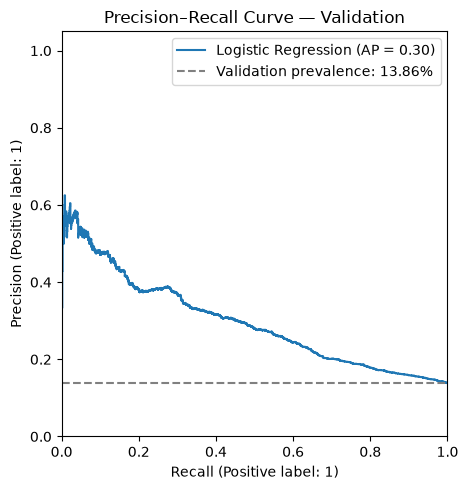

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

PrecisionRecallDisplay.from_predictions(
    y_valid,
    y_valid_proba,
    name="Logistic Regression",
    ax=ax,
)

ax.axhline(
    validation_base_rate,
    color="gray",
    linestyle="--",
    label=f"Validation prevalence: {validation_base_rate:.2%}",
)

ax.set_title("Precision–Recall Curve — Validation")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()

#### Observations

The recorded baseline results show ranking discrimination
above the constant-score reference:

- AP: 0.297231.
- ROC-AUC: 0.692923.
- Validation prevalence: approximately 13.86%.

At the top 10%:

- 824 customers are selected.
- 318 observed subscribers are captured.
- Precision@K is approximately 38.59%.
- Recall@K is approximately 27.85%.
- Lift@K is approximately 2.78.

The selected group therefore contains a higher subscriber
concentration than the overall Validation population.

Across the evaluated capacities, expanding K captures more
subscribers while reducing Precision@K and Lift@K.

Recall@K cannot decrease as K expands for a fixed ranking.
Precision@K and Lift@K are not guaranteed to decrease
for every possible ranking.

These results describe observed historical subscription outcomes.
They do not measure the incremental effect of contacting customers
or establish the most profitable contact policy.

## 5. Baseline Summary

### 5.1 Baseline Configuration & Results

This notebook established the predictive baseline using:

| Component | Configuration |
|---|---|
| Model | LogisticRegression(max_iter=1000) |
| Numerical preprocessing | StandardScaler, including raw `pdays` |
| Categorical preprocessing | OneHotEncoder(handle_unknown="ignore") |
| Modeling inputs | 19 predictors, excluding `duration` |
| Development split | Chronological Train / Validation |
| Final Test | Frozen for final evaluation |

Preprocessing and model parameters were fitted on Train only.

The recorded Validation results are:

| Metric | Result |
|---|---:|
| Average Precision | 0.297231 |
| ROC-AUC | 0.692923 |
| Subscription prevalence | 13.86% |

The Top-K results are recorded in Section 4.2.

For example, the top 10% captures approximately 27.85% of
Validation subscribers, with a Lift@K of approximately 2.78.

These results establish the reference performance for Notebook 04.

### 5.2 Limitations

**Model representation**

Logistic Regression models linear log-odds in the transformed
feature space. It does not automatically capture nonlinear
numerical effects or complex feature interactions.

Raw `pdays` remains a basic representation of a sentinel-heavy
predictor. Its alternatives have not been compared here.

**Temporal generalization**

Train and Validation differ in target prevalence and
economic conditions.

A single chronological validation period provides limited
evidence about performance in other future periods.

**Ranking evaluation**

Top-K evaluation treats the whole Validation period as one pool.

It does not simulate daily customer availability, repeated-contact
restrictions, or a daily call-center budget.

The capacities are comparison scenarios rather than
a selected operational policy.

**Business interpretation**

Ranking metrics describe concentration of observed subscribers.
They do not estimate causal contact effects or financial return.

**Probability calibration**

Predicted probabilities are used as ranking scores.
Their reliability as absolute subscription probabilities
has not been evaluated.

### 5.3 Next Experiments

`04-model-experiments.ipynb` will:

1. Reproduce this baseline under the same evaluation protocol.
2. Compare justified feature and preprocessing alternatives,
   including alternative `pdays` representations.
3. Compare candidate models with appropriate preprocessing.
4. Tune promising configurations.
5. Analyze errors, subgroup performance, and interpretability.
6. Select the final configuration using Validation evidence.

AP remains the primary model-selection metric.

ROC-AUC and Top-K metrics provide additional evidence about
ranking quality and contact-capacity trade-offs.

Preserve:

- The chronological split.
- Prediction-time feature availability assumptions.
- The contact-capacity comparison points.
- The K rounding and tie-breaking rules.

When repeated evaluation logic becomes stable, move it into
`src/bank_marketing_ml/evaluate.py` with appropriate tests.

Test remains frozen for final evaluation in
`05-final-evaluation.ipynb`.